# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal

To analyze agricultural data across different seasons and identify meaningful patterns, trends, relationships, and variations in agricultural performance.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed under different seasonal conditions.

Therefore, this project analyzes the given agricultural dataset to investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

## 2. Project Objectives

The objectives of this project are to:

1. Understand the structure and quality of the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine how agricultural performance varies across seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between environmental conditions and agricultural outcomes.
6. Compare agricultural performance across relevant groups.
7. Identify unusual patterns and significant observations.
8. Apply appropriate statistical and visualization techniques.
9. Develop evidence-based insights.
10. Provide data-driven recommendations.

## 3. Dataset Description

The dataset contains farm-level agricultural records covering different seasons, geographical locations, crops, environmental conditions, farming practices, production, economic performance, and resource usage.

The dataset contains information about:

- Farm and geographical characteristics
- Crop and season
- Environmental conditions
- Soil characteristics
- Agricultural inputs
- Irrigation methods
- Crop yield and production
- Market price and economic performance
- Water usage and efficiency
- Disease and pest risk


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset

file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


In [3]:
# Display the first five records

df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
# Display the last five records

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [5]:
# Display a random sample of five records

df.sample(5, random_state=42)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [6]:
# Display all column names

print("Column names:")
print(df.columns.tolist())

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [7]:
# Examine data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [9]:
# Summary of categorical variables

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 4. Data Quality Assessment and Cleaning

Before performing statistical analysis and visualization, the dataset was examined for missing values, duplicate records, inconsistent data types, and potential data-quality issues.

In [11]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [12]:
# Calculate percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary

,Missing Count,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


In [13]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records

No duplicate records were identified in the dataset. Therefore, no rows were removed on the basis of duplication.

In [14]:
# Handle missing numerical values using median imputation

columns_to_impute = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in columns_to_impute:
    df[column] = df[column].fillna(df[column].median())

print("Missing numerical values have been imputed using the median.")

Missing numerical values have been imputed using the median.


In [15]:
# Verify remaining missing values

remaining_missing = df.isnull().sum().sum()

print("Total remaining missing values:", remaining_missing)

Total remaining missing values: 0


In [19]:
# Check data types after cleaning

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [20]:
# Check unique values of important categorical variables

print("Seasons:")
print(df["Season"].unique())

print("\nCrops:")
print(df["Crop"].unique())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].unique())

Seasons:
['Kharif' 'Rabi' 'Zaid']

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [21]:
# Check minimum and maximum values of numerical variables

numerical_columns = df.select_dtypes(include=np.number).columns

range_check = pd.DataFrame({
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max()
})

range_check

,Minimum,Maximum
Farm_Area_Hectares,0.50,15.00
Rainfall_mm,80.00,"1,395.20"
Avg_Temperature_C,16.20,39.70
Humidity_pct,25.00,95.00
Sunlight_Hours_Day,3.50,11.00
Soil_pH,5.20,8.40
Soil_Moisture_pct,8.00,47.00
Nitrogen_kg_ha,40.00,220.00
Phosphorus_kg_ha,15.00,120.00
Potassium_kg_ha,30.00,200.00


In [22]:
# Final dataset quality summary

print("FINAL DATASET SUMMARY")
print("----------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

FINAL DATASET SUMMARY
----------------------
Rows: 4000
Columns: 28
Duplicate rows: 0
Total missing values: 0


### Data Cleaning Summary

The dataset initially contained 4,000 records and 28 variables. Missing values were identified in Rainfall, Soil Moisture, and Yield. These missing numerical values were handled using median imputation. No duplicate records were identified. After cleaning, the dataset contained 4,000 records, 28 variables, and no remaining missing values.

The cleaned dataset was considered suitable for further statistical analysis and visualization.

## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of agricultural variables and identify patterns, trends, relationships, and differences within the dataset.

### 5.1 Distribution of Agricultural Records Across Seasons

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


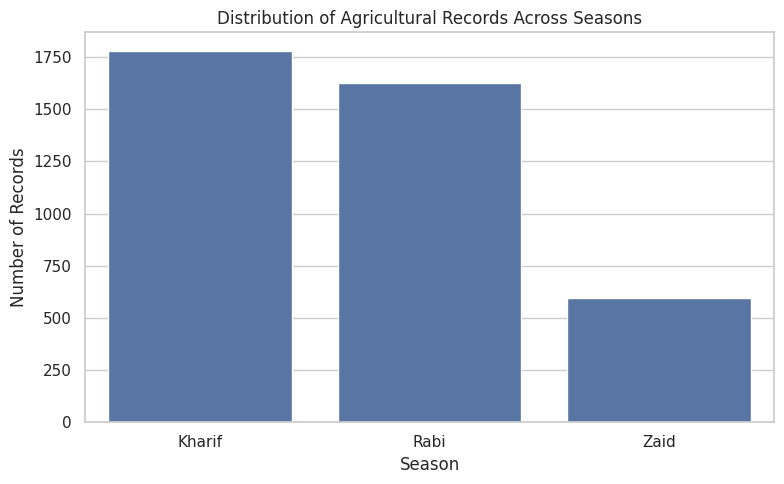

In [23]:
# Count of records by season

season_counts = df["Season"].value_counts()

print(season_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Season")

plt.title("Distribution of Agricultural Records Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Interpretation

The dataset contains agricultural records from three seasons: Kharif, Rabi, and Zaid. Kharif represents the largest proportion of observations, followed by Rabi, while Zaid has comparatively fewer observations.

### 5.2 Distribution of Crops

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


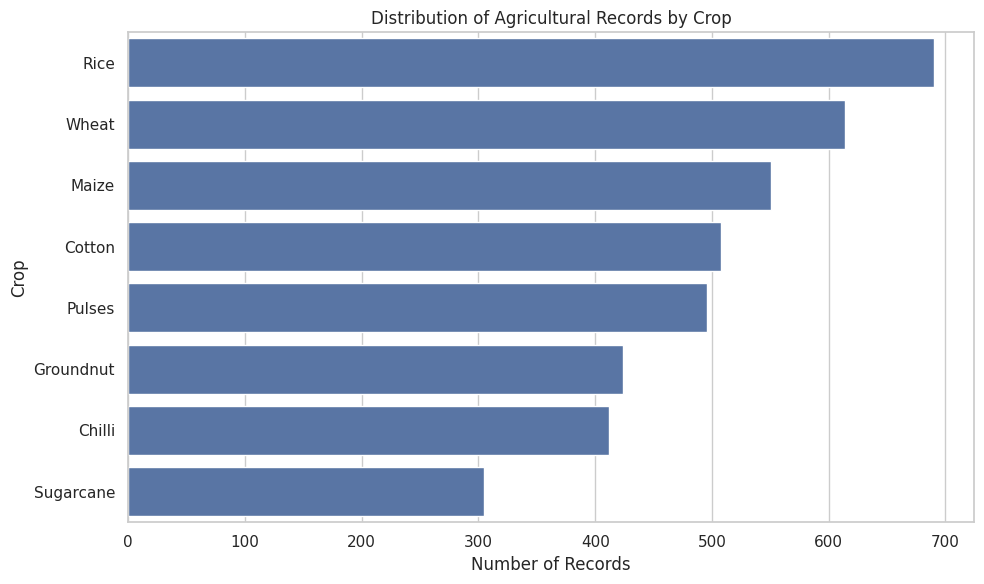

In [24]:
# Distribution of crops

crop_counts = df["Crop"].value_counts()

print(crop_counts)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Crop", order=crop_counts.index)

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Number of Records")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### 5.3 Distribution of Crop Yield

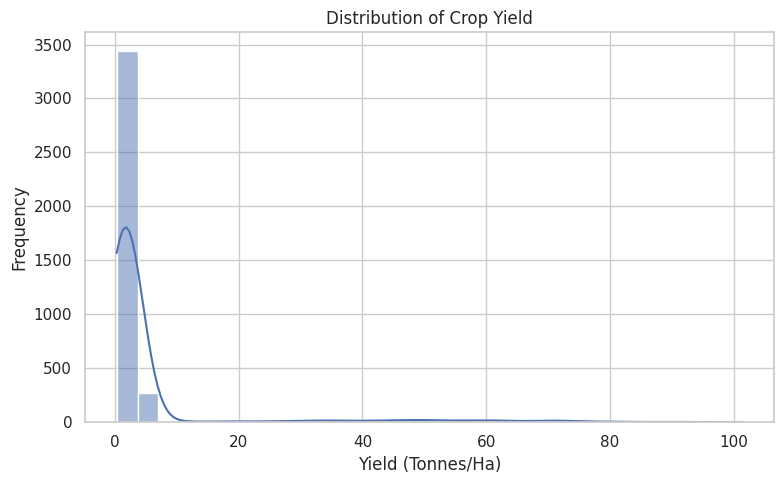

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Yield_Tonnes_Ha",
    bins=30,
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5.4 Distribution of Agricultural Profit

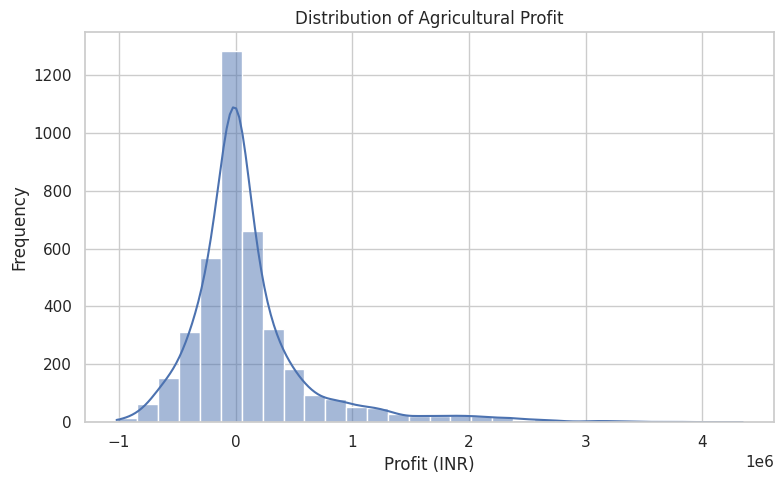

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Profit_INR",
    bins=30,
    kde=True
)

plt.title("Distribution of Agricultural Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5.5 Distribution of Rainfall

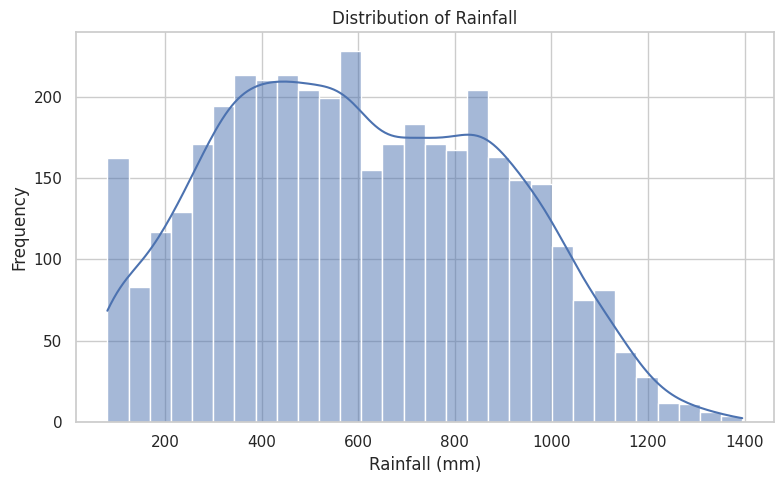

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rainfall_mm",
    bins=30,
    kde=True
)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 6. Outlier Analysis

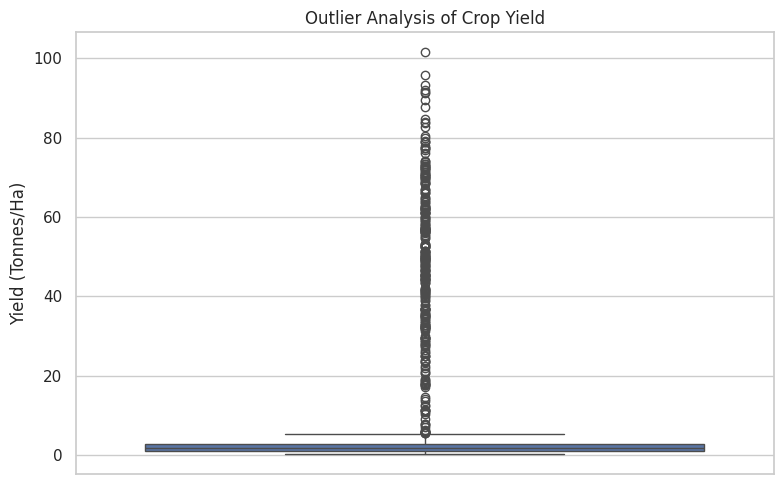

In [28]:
# Boxplot for Yield

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, y="Yield_Tonnes_Ha")

plt.title("Outlier Analysis of Crop Yield")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

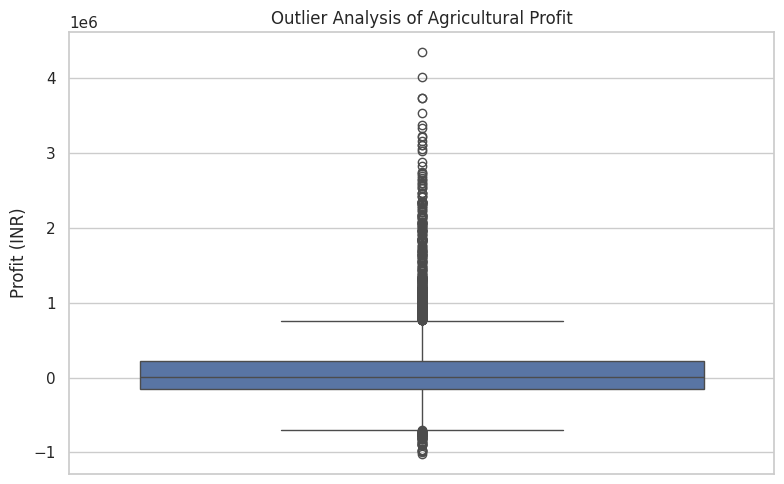

In [29]:
# Boxplot for Profit

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, y="Profit_INR")

plt.title("Outlier Analysis of Agricultural Profit")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show()

## 7. Bivariate Analysis

### 7.1 Seasonal Variation in Average Yield

Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64


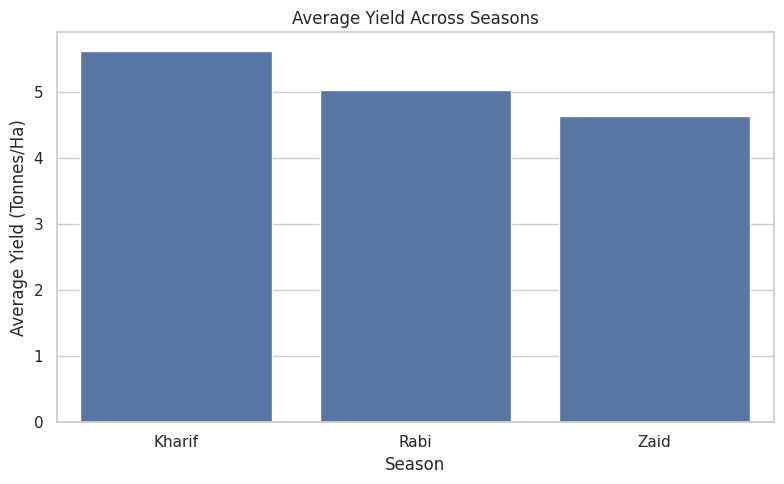

In [30]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(season_yield)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

### Interpretation

Kharif shows the highest average yield among the three seasons, followed by Rabi. Zaid records the lowest average yield. This indicates noticeable seasonal variation in agricultural yield within the dataset.

Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64


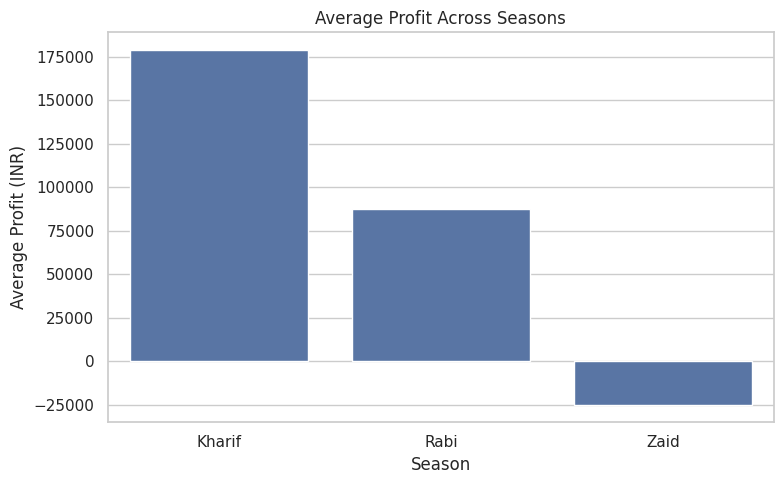

In [31]:
season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

print(season_profit)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

### Interpretation

Kharif records the highest average profit, while Zaid records a negative average profit. This indicates substantial differences in economic performance across seasons within the dataset.

Irrigation_Method
Drip        6.58
Sprinkler   5.16
Flood       4.86
Rainfed     4.60
Name: Yield_Tonnes_Ha, dtype: float64


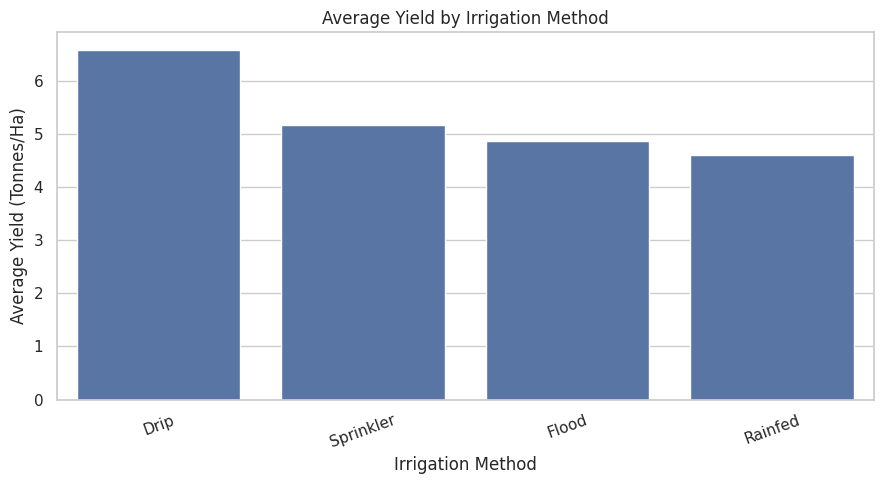

In [32]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(irrigation_yield)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

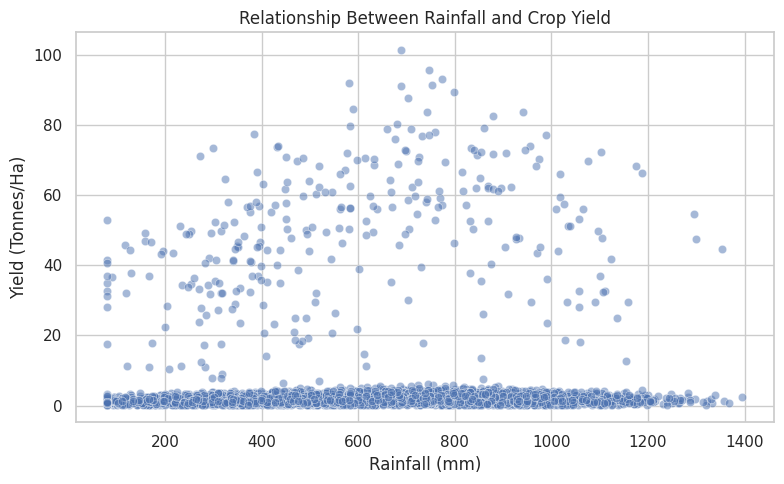

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    alpha=0.5
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [34]:
rainfall_yield_corr = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])

print(
    "Correlation between Rainfall and Yield:",
    round(rainfall_yield_corr, 3)
)

Correlation between Rainfall and Yield: 0.031


### Interpretation

Rainfall and crop yield show a very weak positive correlation in the dataset. This suggests that rainfall alone does not explain much of the variation in crop yield. Other environmental, agricultural, and operational factors may also contribute to differences in yield.

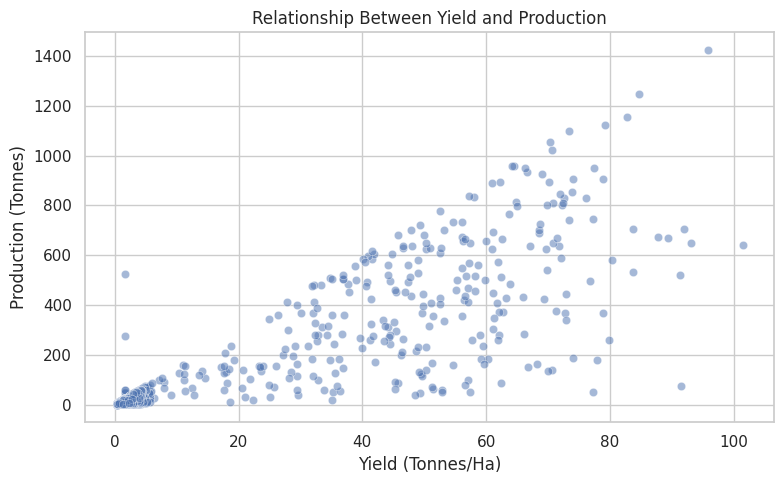

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Production_Tonnes",
    alpha=0.5
)

plt.title("Relationship Between Yield and Production")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

## 8. Multivariate Analysis

Multivariate analysis was performed to examine multiple agricultural variables simultaneously and identify patterns that may not be visible when variables are analyzed individually.

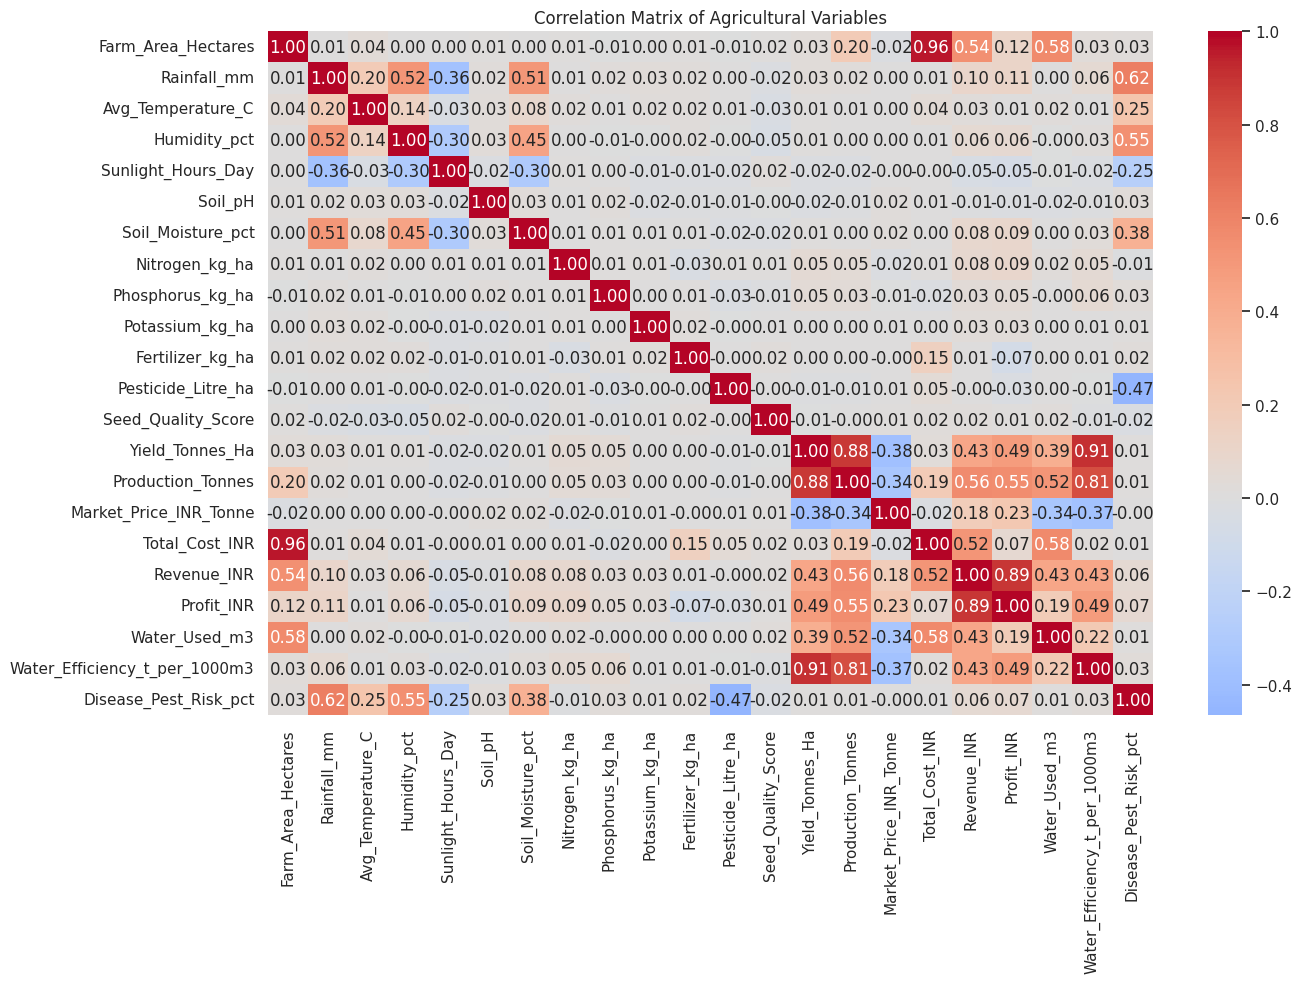

In [36]:
# Select numerical variables for correlation analysis

numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.tight_layout()
plt.show()

In [37]:
# Correlations with crop yield

yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


## 9. Seasonal Performance Analysis

Agricultural performance was compared across Kharif, Rabi, and Zaid seasons using yield, production, profit, revenue, cost, and water usage.

In [40]:
# Compare key agricultural performance indicators across seasons

season_performance = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
)

season_performance.round(2)

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used
Season,,,,,,
Kharif,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20"
Rabi,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99"
Zaid,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89"


### 9.1 Seasonal Performance: Yield

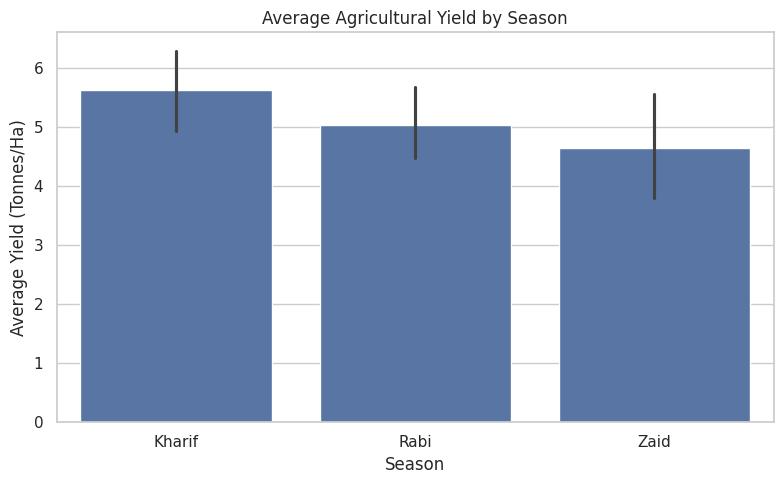

In [41]:
# Average yield across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

### 9.2 Seasonal Performance: Profit

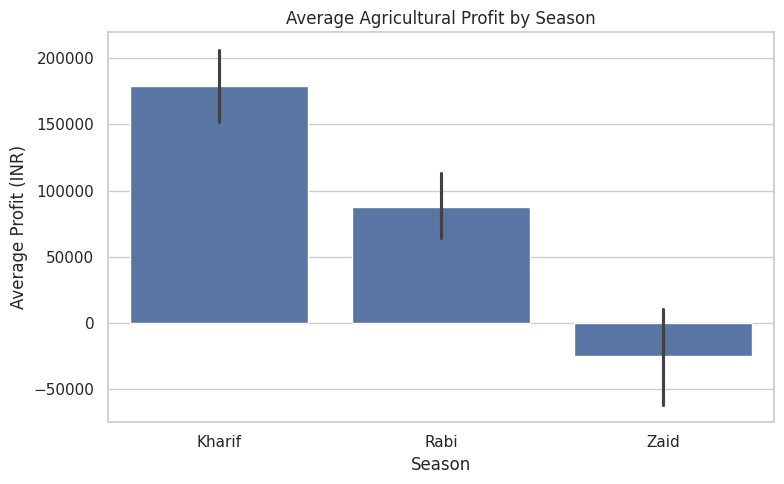

In [42]:
# Average profit across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    estimator="mean"
)

plt.title("Average Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.show()

### 9.3 Seasonal Performance: Water Usage

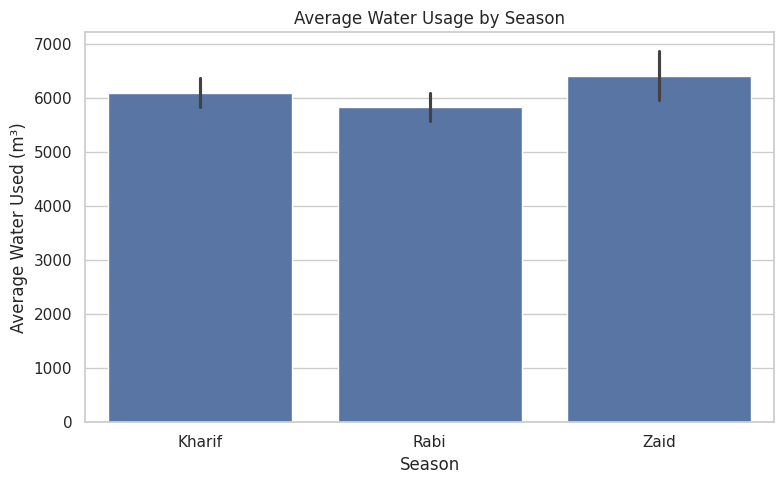

In [43]:
# Average water usage across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    estimator="mean"
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")

plt.tight_layout()
plt.show()

### 9.4 Crop Yield Across Different Seasons

This analysis examines how crop yield varies simultaneously across crop categories and agricultural seasons.

In [44]:
# Average yield by crop and season

crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


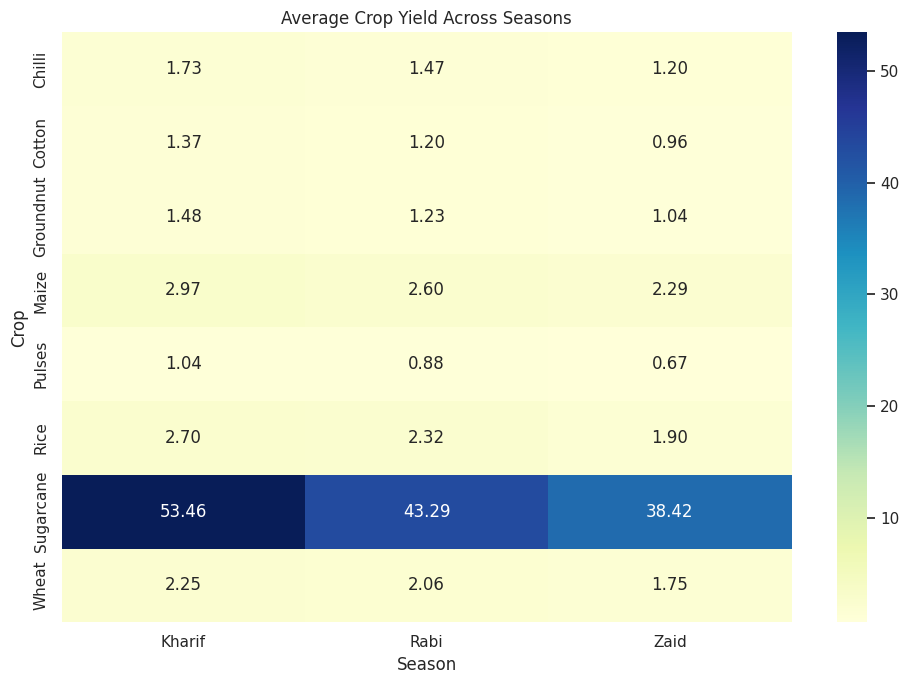

In [45]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

### 9.5 Irrigation Method and Seasonal Yield

In [46]:
# Average yield by irrigation method and season

irrigation_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
)

irrigation_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.11,5.85
Flood,4.98,5.06,3.98
Rainfed,5.70,3.93,3.06
Sprinkler,4.66,5.31,6.14


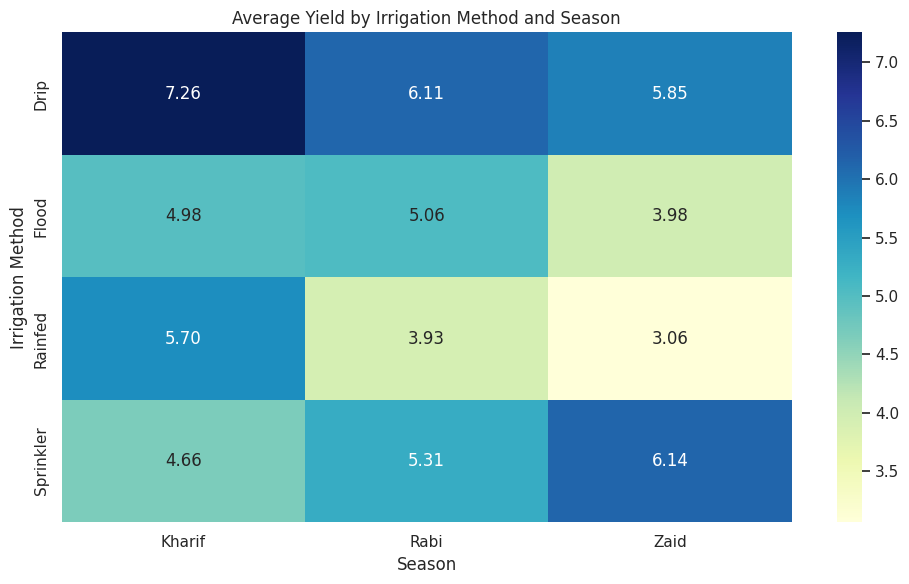

In [47]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    irrigation_season_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")

plt.tight_layout()
plt.show()

## 10. Correlation Analysis

Correlation analysis was used to examine the strength and direction of linear relationships between numerical agricultural variables.

In [48]:
# Create correlation matrix

numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

correlation_matrix.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


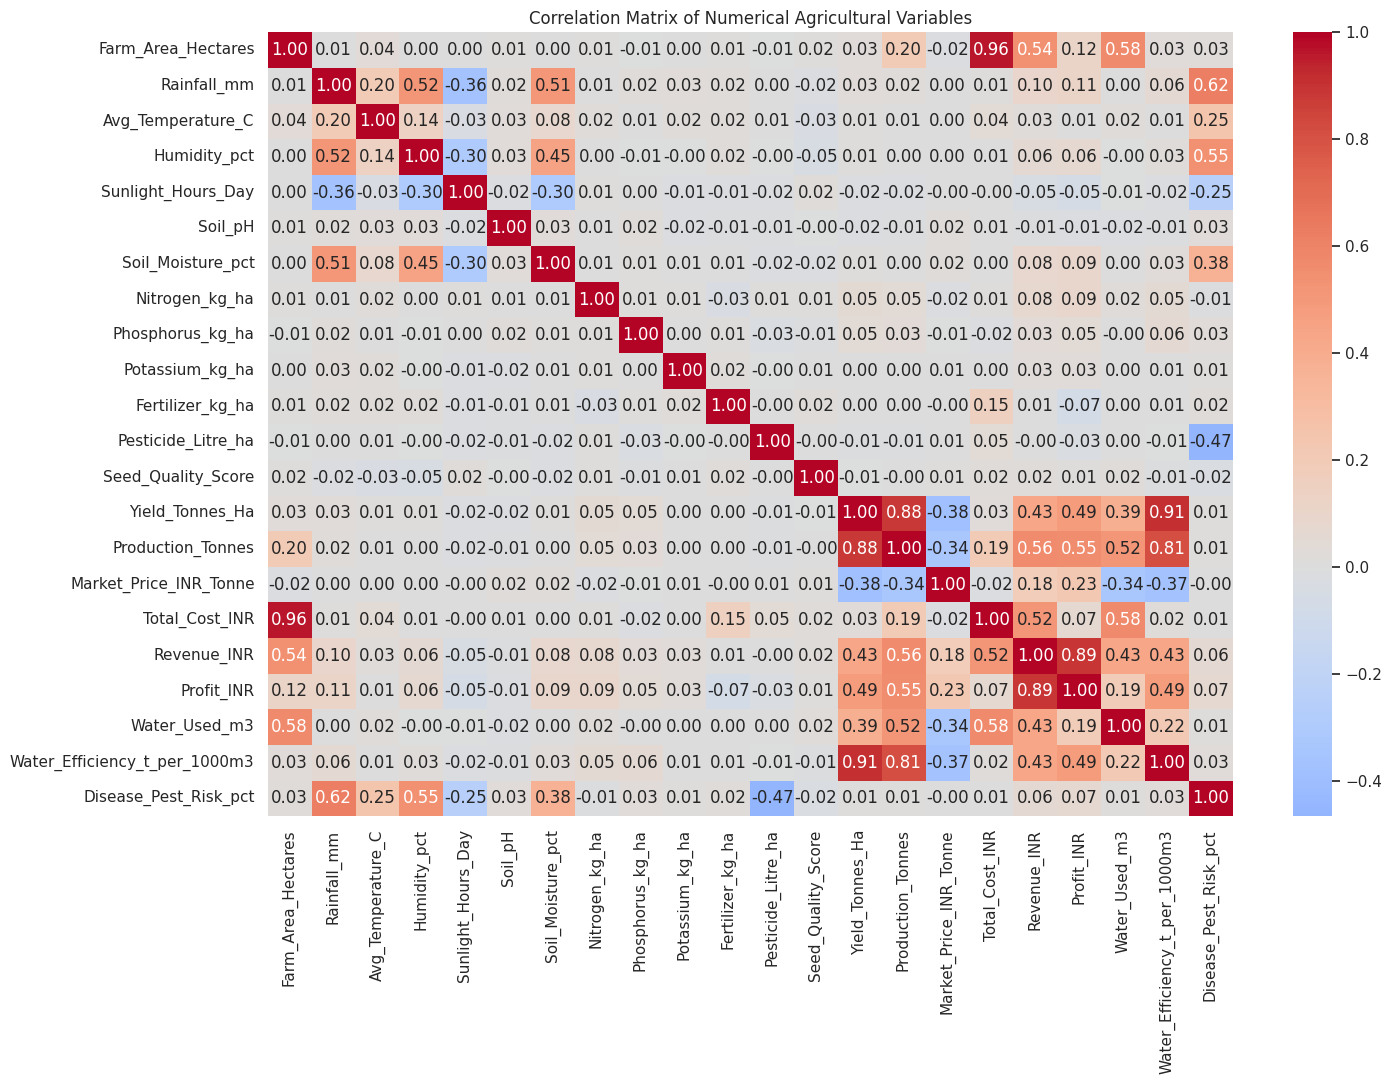

In [49]:
plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Agricultural Variables")

plt.tight_layout()
plt.show()

In [50]:
# Variables most strongly associated with yield

yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_correlations.round(3)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


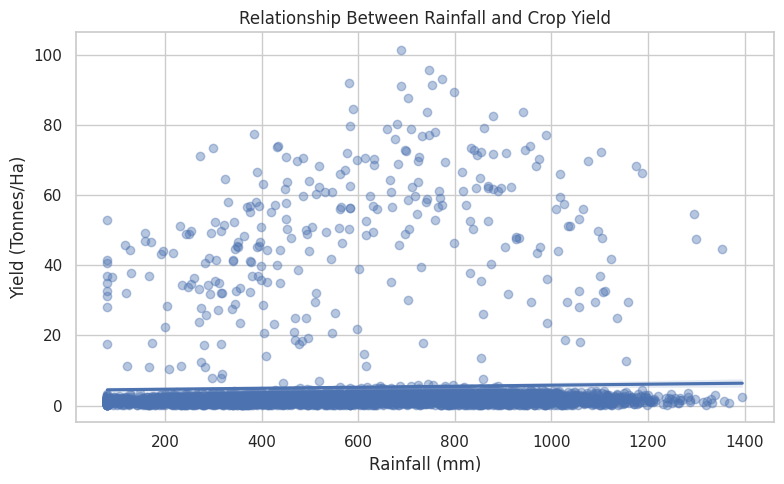

In [51]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    scatter_kws={"alpha": 0.4}
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [52]:
rainfall_yield_corr = df[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr()

rainfall_yield_corr.round(3)

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.00,0.03
Yield_Tonnes_Ha,0.03,1.00


## 11. Student-Designed Analysis 1
### Irrigation Method and Agricultural Yield

**Analytical Question:**  
Which irrigation method is associated with the highest average agricultural yield?

This analysis compares average yield across different irrigation methods and examines whether noticeable differences exist between them.

In [53]:
irrigation_analysis = (
    df.groupby("Irrigation_Method")
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Water_Used=("Water_Used_m3", "mean")
    )
    .sort_values("Average_Yield", ascending=False)
)

irrigation_analysis.round(2)

,Average_Yield,Average_Water_Used
Irrigation_Method,,
Drip,6.58,"5,918.75"
Sprinkler,5.16,"6,208.26"
Flood,4.86,"8,026.47"
Rainfed,4.60,"3,549.55"


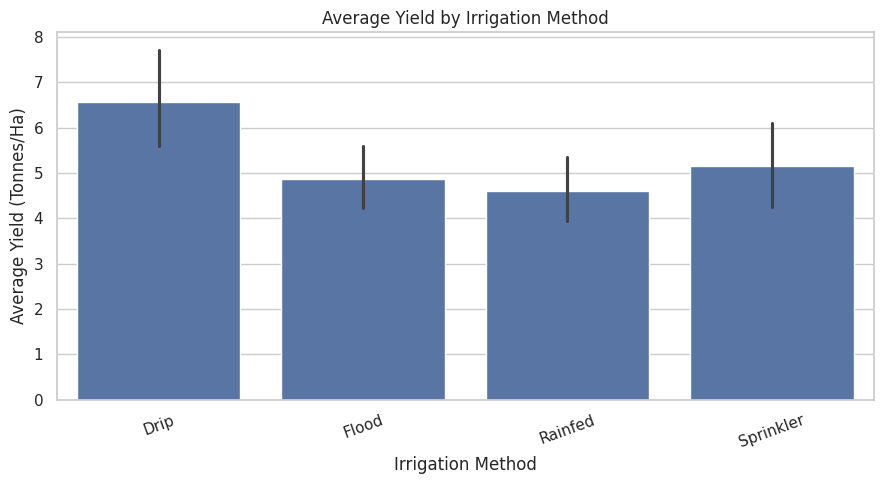

In [54]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. Student-Designed Analysis 2
### Crop Performance Comparison

**Analytical Question:**  
How does average agricultural yield differ across different crops?

This analysis compares average yield and profitability across crop categories.

In [55]:
crop_analysis = (
    df.groupby("Crop")
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .sort_values("Average_Yield", ascending=False)
)

crop_analysis.round(2)

,Average_Yield,Average_Profit
Crop,,
Sugarcane,46.64,"817,187.99"
Maize,2.71,"-83,978.33"
Rice,2.43,"-102,213.50"
Wheat,2.11,"-123,398.34"
Chilli,1.54,"750,878.34"
Groundnut,1.32,"44,858.12"
Cotton,1.23,"124,546.92"
Pulses,0.92,"-4,238.05"


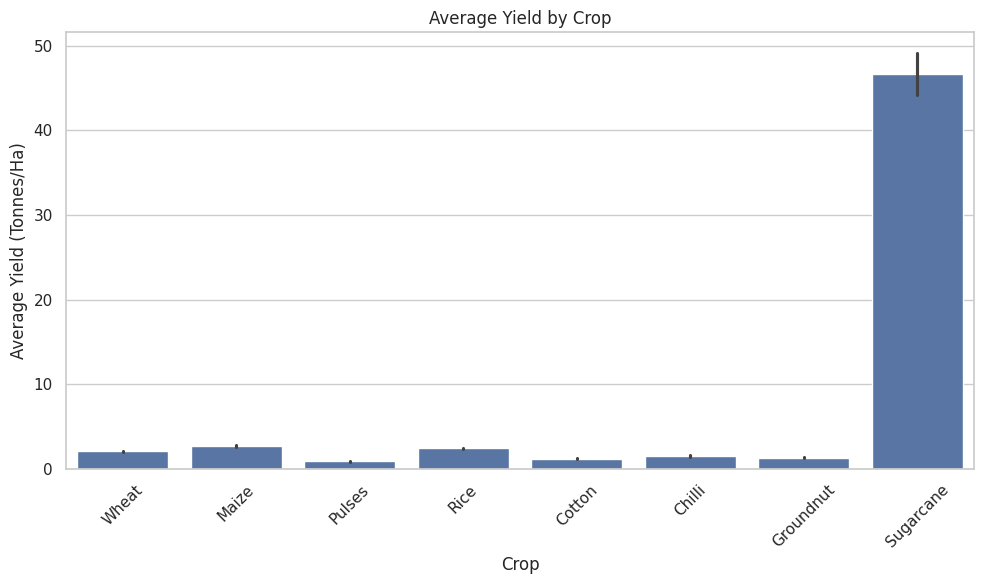

In [56]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    estimator="mean"
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Student-Designed Analysis 3
### Rainfall and Agricultural Yield

**Analytical Question:**  
Is rainfall strongly associated with agricultural yield?

This analysis examines the relationship between rainfall and crop yield using correlation and regression visualization.

In [57]:
rainfall_yield_corr_value = df[
    "Rainfall_mm"
].corr(df["Yield_Tonnes_Ha"])

print(
    "Correlation between Rainfall and Yield:",
    round(rainfall_yield_corr_value, 3)
)

Correlation between Rainfall and Yield: 0.031


# 14. Final Results Summary

The following tables summarize the major findings obtained from the exploratory, seasonal, correlation, and student-designed analyses.

In [58]:
# ==========================================
# FINAL RESULTS SUMMARY
# ==========================================

# 1. Seasonal performance
season_results = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

print("===== SEASONAL PERFORMANCE =====")
display(season_results)


# 2. Irrigation performance
irrigation_results = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Profit=("Profit_INR", "mean")
).sort_values("Average_Yield", ascending=False).round(2)

print("\n===== IRRIGATION PERFORMANCE =====")
display(irrigation_results)


# 3. Crop performance
crop_results = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).sort_values("Average_Yield", ascending=False).round(2)

print("\n===== CROP PERFORMANCE =====")
display(crop_results)


# 4. Rainfall-Yield correlation
rainfall_corr = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])

print("\n===== RAINFALL-YIELD RELATIONSHIP =====")
print("Rainfall-Yield Correlation:", round(rainfall_corr, 3))


# 5. Strongest numerical correlations with yield
yield_corr = (
    df.select_dtypes(include=np.number)
      .corr()["Yield_Tonnes_Ha"]
      .sort_values(ascending=False)
      .round(3)
)

print("\n===== CORRELATIONS WITH YIELD =====")
display(yield_corr)

===== SEASONAL PERFORMANCE =====


,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used
Season,,,,,,
Kharif,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20"
Rabi,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99"
Zaid,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89"



===== IRRIGATION PERFORMANCE =====


,Average_Yield,Average_Water_Used,Average_Profit
Irrigation_Method,,,
Drip,6.58,"5,918.75","219,626.00"
Sprinkler,5.16,"6,208.26","91,121.08"
Flood,4.86,"8,026.47","73,354.02"
Rainfed,4.60,"3,549.55","79,050.37"



===== CROP PERFORMANCE =====


,Average_Yield,Average_Profit
Crop,,
Sugarcane,46.64,"817,187.99"
Maize,2.71,"-83,978.33"
Rice,2.43,"-102,213.50"
Wheat,2.11,"-123,398.34"
Chilli,1.54,"750,878.34"
Groundnut,1.32,"44,858.12"
Cotton,1.23,"124,546.92"
Pulses,0.92,"-4,238.05"



===== RAINFALL-YIELD RELATIONSHIP =====
Rainfall-Yield Correlation: 0.031

===== CORRELATIONS WITH YIELD =====


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


In [59]:
# ==========================================
# BEST AND WORST PERFORMERS
# ==========================================

best_season_yield = season_results["Average_Yield"].idxmax()
worst_season_yield = season_results["Average_Yield"].idxmin()

best_season_profit = season_results["Average_Profit"].idxmax()
worst_season_profit = season_results["Average_Profit"].idxmin()

best_irrigation = irrigation_results["Average_Yield"].idxmax()
worst_irrigation = irrigation_results["Average_Yield"].idxmin()

best_crop = crop_results["Average_Yield"].idxmax()
worst_crop = crop_results["Average_Yield"].idxmin()

print("BEST SEASON BY YIELD:", best_season_yield)
print("WORST SEASON BY YIELD:", worst_season_yield)

print("\nBEST SEASON BY PROFIT:", best_season_profit)
print("WORST SEASON BY PROFIT:", worst_season_profit)

print("\nBEST IRRIGATION METHOD BY YIELD:", best_irrigation)
print("LOWEST IRRIGATION METHOD BY YIELD:", worst_irrigation)

print("\nHIGHEST-YIELDING CROP:", best_crop)
print("LOWEST-YIELDING CROP:", worst_crop)

print("\nRAINFALL-YIELD CORRELATION:", round(rainfall_corr, 3))

BEST SEASON BY YIELD: Kharif
WORST SEASON BY YIELD: Zaid

BEST SEASON BY PROFIT: Kharif
WORST SEASON BY PROFIT: Zaid

BEST IRRIGATION METHOD BY YIELD: Drip
LOWEST IRRIGATION METHOD BY YIELD: Rainfed

HIGHEST-YIELDING CROP: Sugarcane
LOWEST-YIELDING CROP: Pulses

RAINFALL-YIELD CORRELATION: 0.031


In [60]:
# Save cleaned dataset

cleaned_file = "/content/cleaned_seasonal_agriculture_performance_dataset.csv"

df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully!")
print(cleaned_file)

Cleaned dataset saved successfully!
/content/cleaned_seasonal_agriculture_performance_dataset.csv


# 15. Key Insights

The following insights were derived from the statistical analysis, visualizations, seasonal comparisons, correlation analysis, and student-designed analyses.

## 16. Statistical Analysis

### One-Way ANOVA: Seasonal Differences in Yield

A one-way Analysis of Variance (ANOVA) was conducted to determine whether the mean agricultural yield differs significantly across Kharif, Rabi, and Zaid seasons.

**Null Hypothesis (H₀):**  
There is no significant difference in mean yield across the three seasons.

**Alternative Hypothesis (H₁):**  
At least one season has a significantly different mean yield.

In [61]:
# One-way ANOVA for yield across seasons

from scipy.stats import f_oneway

kharif_yield = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi_yield = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid_yield = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

anova_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", round(anova_stat, 3))
print("p-value:", p_value)

ANOVA F-statistic: 1.544
p-value: 0.21367813841792296


In [62]:
# Interpret the ANOVA result

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("There is a statistically significant difference in mean yield across seasons.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in mean yield across seasons.")

Result: Fail to reject the null hypothesis.
There is no statistically significant difference in mean yield across seasons.


# 15. Key Insights

### Insight 1 — Kharif shows the highest average yield

Kharif recorded the highest average yield at approximately **5.63 tonnes/ha**, compared with **5.04 tonnes/ha** for Rabi and **4.64 tonnes/ha** for Zaid. This indicates noticeable variation in agricultural productivity across seasons.

### Insight 2 — Kharif demonstrates the strongest average profitability

Kharif recorded the highest average profit of approximately **₹178,914.65**, while Rabi recorded approximately **₹87,689.47**. Zaid recorded a negative average profit of approximately **−₹24,804.82**, indicating comparatively weaker economic performance.

### Insight 3 — Zaid combines high water usage with lower yield

Zaid recorded the highest average water usage at approximately **6,419.89 m³**, while also recording the lowest average yield of approximately **4.64 tonnes/ha**. This suggests that higher water usage does not necessarily correspond to higher yield.

### Insight 4 — Drip irrigation shows the highest average yield

Among the irrigation methods, Drip irrigation recorded the highest average yield at approximately **6.58 tonnes/ha**, followed by Sprinkler at **5.16 tonnes/ha**, Flood at **4.86 tonnes/ha**, and Rainfed at **4.60 tonnes/ha**.

This represents an association in the dataset and should not be interpreted as proof that irrigation method alone causes higher yield.

### Insight 5 — Sugarcane has substantially higher average yield

Sugarcane recorded an average yield of approximately **46.64 tonnes/ha**, substantially higher than the other crops shown in the analysis. This large difference should be interpreted carefully because crop characteristics and differences in production scale may contribute to the result.

### Insight 6 — Yield has a very strong relationship with water efficiency

Water efficiency showed a strong positive correlation of approximately **0.91** with yield. This indicates that farms with higher measured water-use efficiency tend to have higher yields in the dataset.

Correlation, however, does not establish causation.

### Insight 7 — Yield is strongly associated with production

Production showed a strong positive correlation of approximately **0.88** with yield. This is expected because both measures are related to agricultural productivity, although they represent different aspects of performance.

### Insight 8 — Rainfall alone has a very weak relationship with yield

Rainfall showed a correlation of approximately **0.03** with yield. This indicates that rainfall alone has very little linear association with yield in this dataset. Other environmental, agricultural, operational, and economic variables may contribute to differences in agricultural performance.

# 17. Recommendations

Based on the findings of the analysis, the following recommendations are proposed:

1. **Season-specific planning:** Agricultural planning should consider differences in yield and profitability across Kharif, Rabi, and Zaid rather than applying identical strategies across all seasons.

2. **Improve water-use efficiency:** Since water efficiency has a strong positive association with yield, improving water-use efficiency should be considered an important area for agricultural planning and further investigation.

3. **Evaluate irrigation practices:** Drip irrigation showed the highest average yield among the irrigation methods analyzed. Its effectiveness should be investigated further while considering cost, crop type, soil conditions, and seasonal requirements.

4. **Review Zaid-season economics:** The negative average profit observed for Zaid suggests that the economic feasibility of Zaid-season farming should be examined carefully.

5. **Promote evidence-based crop planning:** Large differences in yield between crops indicate that crop selection and seasonal suitability should be considered when planning agricultural activities.

6. **Use multiple factors for decision-making:** Since rainfall alone has a very weak correlation with yield, agricultural decisions should consider several environmental and operational variables together.

7. **Improve future data collection:** Future datasets should include more years, locations, crop-specific information, and detailed input/output measures to support more reliable conclusions.

# 18. Limitations

1. The analysis is based on the available dataset and may not represent all agricultural regions or farming conditions.

2. The dataset contains observations from specific crops, seasons, locations, and farming conditions; therefore, the findings may not generalize to all agricultural contexts.

3. Missing numerical values were handled using median imputation, which may not perfectly represent the original observations.

4. Correlation identifies linear association but does not establish causation.

5. The very high average yield observed for Sugarcane should be interpreted cautiously because crop-specific characteristics may influence the comparison.

6. Seasonal comparisons may be affected by differences in crop composition, irrigation methods, geographical conditions, and other factors.

7. The analysis is primarily descriptive and does not develop a predictive machine-learning model.

8. Additional multi-year data would be useful for determining whether the observed patterns remain consistent over time.

# 19. Conclusion

This project analyzed seasonal agricultural performance using data cleaning, descriptive statistics, visualization, correlation analysis, multivariate analysis, and statistical testing. The results revealed clear differences in agricultural performance across Kharif, Rabi, and Zaid seasons. Kharif recorded the highest average yield and profitability, while Zaid recorded the lowest average yield and a negative average profit despite having the highest average water usage.

The analysis also showed differences across irrigation methods and crops. Drip irrigation recorded the highest average yield among the irrigation methods, while Sugarcane showed substantially higher average yield than the other crops analyzed. Water efficiency and production showed strong positive associations with yield, whereas rainfall showed a very weak linear relationship with yield.

Overall, the findings demonstrate that agricultural performance is influenced by multiple interacting factors and that data analytics can support evidence-based seasonal planning, resource management, and agricultural decision-making.

In [63]:
from scipy.stats import f_oneway

kharif_yield = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi_yield = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid_yield = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

anova_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", round(anova_stat, 3))
print("p-value:", p_value)

if p_value < 0.05:
    print("\nConclusion: Reject H0.")
    print("There is a statistically significant difference in mean yield across seasons.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("There is no statistically significant difference in mean yield across seasons.")

ANOVA F-statistic: 1.544
p-value: 0.21367813841792296

Conclusion: Fail to reject H0.
There is no statistically significant difference in mean yield across seasons.


# 20. Executive Summary

This project analyzed 4,000 agricultural records containing 28 variables related to crop production, environmental conditions, farming practices, resource usage, and economic performance.

The analysis involved data cleaning, descriptive statistics, univariate and bivariate analysis, multivariate analysis, correlation analysis, seasonal comparison, and a one-way ANOVA. Three student-designed analyses were also conducted to investigate irrigation methods, crop performance, and the relationship between rainfall and yield.

The results showed differences in agricultural performance across Kharif, Rabi, and Zaid seasons. Kharif demonstrated the highest average yield and profitability, whereas Zaid showed comparatively lower yield and negative average profitability. Drip irrigation recorded the highest average yield among the irrigation methods analyzed. Water efficiency showed a strong positive association with yield, while rainfall showed a very weak linear association.

The findings demonstrate how data analytics can be used to identify agricultural patterns and support evidence-based decision-making.